## Homework 2: Regression

This is the personal implementation of the homework 2 of [ML Zoomcamp 2026](https://github.com/DataTalksClub/machine-learning-zoomcamp).

In [2]:
# get the data
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-09-19 18:57:00--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.007s  

2026-09-19 18:57:01 (81.1 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [3]:
# prepare the dataset using: 'engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg'
import pandas as pd

df = pd.read_csv("car_fuel_efficiency_2026.csv")
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

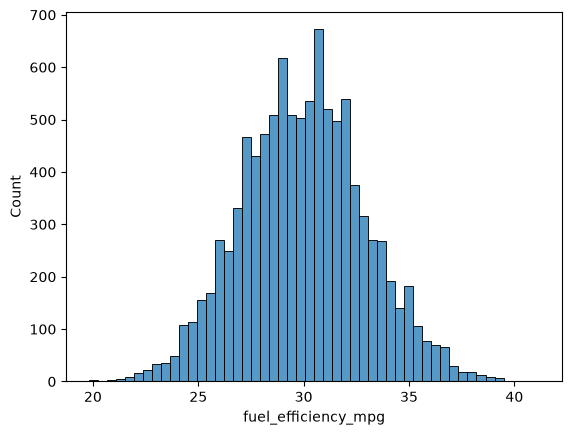

In [ ]:
# look at the fuel_efficiency_mpg variable. Does it have a long tail?
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

sns.histplot(df.fuel_efficiency_mpg, bins=50)

Since the car fuel efficiency has no long tail, we do not need to zoom in or log transform the data.

#### Q1. What is the column with missing values?

In [16]:
missing = df.isnull().sum()

print(missing)
print("The column with missing values: ", missing[missing != 0].index[0])

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64
The column with missing values:  horsepower


#### Q2. What is the median (50% percentile) for 'horsepower'?

In [21]:
print("Median of 'horsepower': ", df['horsepower'].median())

Median of 'horsepower':  254.0


In [27]:
import numpy as np

# prepare and split the data
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# perform shuffle
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

# separate data sets after shuffle and reset index
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

# get y variable as fuel efficiency column for training (no log transformations)
y_train = df_train.fuel_efficiency_mpg.values # get as np array and not series using 'values'
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

# remove fuel efficiency from data to avoid having it as a training feature
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# check out data and y size for each set
print(f"Train, Val, Test: ({len(df_train)}, {len(df_val)}, {len(df_test)})")
print(f"y_train, y_val, y_test: ({len(y_train)}, {len(y_val)}, {len(y_test)})")

# check out train data
df_train.head(3)

Train, Val, Test: (6000, 2000, 2000)
y_train, y_val, y_test: (6000, 2000, 2000)


,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022


#### Q3. Handle missing values for the column from Q1 in 2 ways. Which option gives better RMSE?

1. Filling it with 0
2. Filling it with the mean of that variable

For each, train a linear regression model without regularization. Use only training to compute mean.
Use the validation dataset to evaluate the models and compare the RMSE of each option.
Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.

In [34]:
# define trainiing function
def train_linear_regression(X, y):
    """
    Trains a linear regression model using the normal equation.

    A column of ones is added to X to learn the bias term w0.
    The weights are calculated as:
        w = (X.T @ X)^(-1) @ X.T @ y

    Parameters:
        X (ndarray): Feature matrix.
        y (ndarray): Target values.

    Returns:
        tuple:
            w0 (float): Bias/intercept.
            w (ndarray): Weights for the input features.
    """
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

# define rmse function
def rmse(y, y_pred):
    """
    Computes the Root Mean Squared Error (RMSE) between actual and predicted values.

    Parameters:
        y (ndarray): Actual target values.
        y_pred (ndarray): Predicted target values.

    Returns:
        float: RMSE value.
    """
    return np.sqrt(((y - y_pred) ** 2).mean())


# define function to prepare feature matrix using a value
def prepare(df, val):
    return df.fillna(val).values

In [35]:
mean = df_train['horsepower'].mean()
print("Mean of 'horsepower' (using training data only): ", mean)

# prepare feature matrix for both options
X_train_0 = prepare(df_train, 0)
X_train_mean = prepare(df_train, mean)

# get bias and weights for both options
bias_0, w_0 = train_linear_regression(X_train_0, y_train)
bias_mean, w_mean = train_linear_regression(X_train_mean, y_train)

# prepare validation feature matrix for both options
X_val_0 = prepare(df_val, 0)
X_val_mean = prepare(df_val, mean)

# get predictions for validation data
y_pred_0 = bias_0 + X_val_0.dot(w_0)
y_pred_mean = bias_mean + X_val_mean.dot(w_mean)

# get rmse for both options
score_0 = round(rmse(y_val, y_pred_0), 3)
score_mean = round(rmse(y_val, y_pred_mean), 3)
print("RMSE for 0-fill: ", score_0)
print("RMSE for mean-fill: ", score_mean)

Mean of 'horsepower' (using training data only):  254.46338337605272
RMSE for 0-fill:  2.205
RMSE for mean-fill:  2.202


Although the difference is not much, **mean** is the correct option. RMSE values are different from the lecture since here we did not need log transformation.

#### Q4. Train a regularized linear regression. Which r gives the best RMSE?

- For this question, fill the missing values with 0.
- Try different values of r from: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- If multiple options give the same best RMSE, select the smallest r.

In [36]:
def train_linear_regression_reg(X, y, r):
    """
    Trains a regularized linear regression model using the normal equation.

    Regularization adds r to the diagonal of X.T @ X to stabilize
    the solution and prevent extremely large weights.

    Parameters:
        X (ndarray): Feature matrix.
        y (ndarray): Target values.
        r (float): Regularization strength.

    Returns:
        tuple:
            w0 (float): Bias/intercept.
            w (ndarray): Regularized feature weights.
    """
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [49]:
# prepare feature matrix for training and validation data
X_train = prepare(df_train, 0)
X_val = prepare(df_val, 0)

min_score, min_r = 100, 0

# try different regularization parameters
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    bias, w = train_linear_regression_reg(X_train, y_train, r)
    y_pred = bias + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 4)
    print(f"r: {r} | Bias: {bias} | RMSE: {score}")
    if score < min_score:
        min_score, min_r = score, r

print("\nMin RMSE: ", min_score, " with r: ", min_r)

r: 0 | Bias: -153.88496188223104 | RMSE: 2.2053
r: 0.01 | Bias: -148.3092124404723 | RMSE: 2.2058
r: 0.1 | Bias: -111.83871039307081 | RMSE: 2.2241
r: 1 | Bias: -32.331865964969374 | RMSE: 2.3492
r: 5 | Bias: -7.772852209978469 | RMSE: 2.4094
r: 10 | Bias: -3.987116416019025 | RMSE: 2.4195
r: 100 | Bias: -0.4082196488463344 | RMSE: 2.4292

Min RMSE:  2.2053  with r:  0


#### Q5. Find out how seed influences the score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

What's the value of std?

In [51]:
def split_data_with_seed(df, seed):
    """
    Shuffles and splits the dataset into train, validation, and test sets.

    Uses a 60/20/20 split, fills missing values with 0, separates the
    target column, and returns NumPy arrays for features and targets.

    Parameters:
        df (DataFrame): Input dataset.
        seed (int): Random seed used for shuffling.

    Returns:
        tuple:
            X_train, X_val, X_test (ndarray): Feature matrices.
            y_train, y_val, y_test (ndarray): Target arrays.
    """

    # prepare and split the data
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    # perform shuffle
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    # separate data sets after shuffle, reset index, fillna with 0
    df_train = df.iloc[idx[:n_train]].reset_index(drop=True).fillna(0)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True).fillna(0)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True).fillna(0)

    # get y variable as fuel efficiency column for training (no log transformations)
    y_train = df_train.fuel_efficiency_mpg.values # get as np array and not series using 'values'
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    # remove fuel efficiency from data to avoid having it as a training feature
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # get X feature matrix for each set
    X_train = df_train.values
    X_val = df_val.values
    X_test = df_test.values

    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
scores = []

# compare seed values
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    X_train, X_val, X_test, y_train, y_val, y_test = split_data_with_seed(df, s)
    bias, w = train_linear_regression(X_train, y_train)
    y_pred = bias + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 4)
    scores.append(score)
    print(f"s: {s} | Bias: {bias} | RMSE: {score}")

print("Std for scores: ", round(np.std(scores), 3)) # model performance is fairly consistent across different splits.

s: 0 | Bias: -150.42885945053604 | RMSE: 2.2392
s: 1 | Bias: -151.61231559524666 | RMSE: 2.2021
s: 2 | Bias: -152.84068112584038 | RMSE: 2.1634
s: 3 | Bias: -152.33298096679223 | RMSE: 2.2044
s: 4 | Bias: -158.88856816457883 | RMSE: 2.2019
s: 5 | Bias: -151.8573533887713 | RMSE: 2.2458
s: 6 | Bias: -154.3717913727048 | RMSE: 2.2697
s: 7 | Bias: -155.0183525899584 | RMSE: 2.1908
s: 8 | Bias: -150.4381740048234 | RMSE: 2.2166
s: 9 | Bias: -154.36007488958072 | RMSE: 2.207
Std for scores:  0.029


#### Q6. What's the RMSE on the test dataset?
- Split the dataset using seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.

In [54]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data_with_seed(df, 9)
X_full_train = np.vstack([X_train, X_val])
y_full_train = np.concatenate([y_train, y_val])
bias, w = train_linear_regression_reg(X_full_train, y_full_train, 0.001)
y_pred = bias + X_test.dot(w)
score = round(rmse(y_test, y_pred), 3)
print(f"RMSE: {score}")

RMSE: 2.236
